In [25]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report
import time

In [2]:
quartered_df = pd.read_csv("C:\\Users\\User\\Desktop\\quartered_df.csv")

In [26]:
#с половиной исходного датасета
quartered_df = pd.read_csv("C:\\Users\\User\\Desktop\\halfed_df.csv")

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    quartered_df.tokenized_Text,
    quartered_df.number,
    random_state=13,
    test_size=0.25
)

In [27]:
#с необработанным текстом
x_train, x_test, y_train, y_test = train_test_split(
    quartered_df.text,
    quartered_df.number,
    random_state=13,
    test_size=0.25
)

In [28]:
# Векторизация
vec = CountVectorizer(ngram_range=(1, 1))
X_train = vec.fit_transform(x_train)
X_test  = vec.transform(x_test)

In [29]:
# Масштабирование
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [30]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],    # перечень k для перебора
    'weights': ['uniform', 'distance'],         # можно сразу добавить weights
    'metric': ['euclidean', 'manhattan', 'cosine']  # и разные метрики
}

In [31]:
# Настраиваем GridSearchCV
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1_weighted',   # или 'accuracy', 'f1_macro' и т.п.
    cv=5,                    # 5-fold CV
    n_jobs=-1,               # использовать все ядра
    verbose=1                # вывод прогресса
)

In [32]:
# Запускаем поиск
start_time = time.perf_counter()
grid.fit(X_train, y_train)
end_time = time.perf_counter()

Fitting 5 folds for each of 42 candidates, totalling 210 fits


In [33]:
elapsed = end_time - start_time
print(f'Время выполнения скрипта: {elapsed:.4f} секунд')

Время выполнения скрипта: 40439.6597 секунд


In [34]:
# Лучшая комбинация параметров и её F1-score
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'metric': 'cosine', 'n_neighbors': 9, 'weights': 'distance'}
Best CV score: 0.8329043974244558


In [35]:
# Оцениваем на отложенной выборке
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82     14779
           1       0.90      0.80      0.85      6259
           2       0.80      0.85      0.83      3753
           3       0.78      0.80      0.79      6379
           4       0.95      0.96      0.95      3544
           5       0.87      0.70      0.78       928
           7       0.92      0.79      0.85      2399
           8       0.94      0.78      0.85      3127

    accuracy                           0.83     41168
   macro avg       0.87      0.82      0.84     41168
weighted avg       0.84      0.83      0.83     41168



точность до изменений

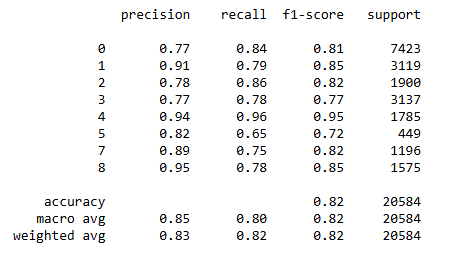